<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Delhi_Metro_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delhi Metro Dataset

Imagine each TripID is a snapshot of a journey within the bustling heart of Delhi. Every Date marks a specific day in the life of the city's metro system, capturing the rhythm of daily commutes, weekend adventures, and festive travels across the years.

The From_Station and To_Station tell countless individual stories – students heading to class, professionals commuting to work, families embarking on outings, and tourists exploring the city's landmarks. The variations in these stations, from major hubs like Rajiv Chowk to smaller, local stops, paint a picture of Delhi's diverse geography and the metro's reach.

Distance_km speaks to the length of these journeys, from short hops between neighboring stations to longer expeditions across the city. This metric, combined with Fare and Cost_per_passenger, reveals the economic side of metro travel – how distance impacts cost and how different ticket types might influence the travel patterns of passengers.

The Passengers, Ticket_Type, and Remarks columns, though removed from our current analysis, hint at deeper stories we could uncover. Were there more passengers during peak hours or on weekends? Did certain ticket types correlate with specific journey types or passenger demographics? Did maintenance work, festivals, or off-peak hours significantly impact ridership or routes?

This dataset, therefore, isn't just rows and columns of numbers it's a collection of millions of stories, each representing a journey, a purpose, and a person navigating the vibrant network of the Delhi Metro. By analyzing these data points, we can understand the pulse of the city, the flow of its people, and the intricate dance of daily life played out across its metro lines.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d nikhilkumar766/delhi-metro-dataset

# Unziping the downloaded file
!unzip delhi-metro-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nikhilkumar766/delhi-metro-dataset
License(s): CC0-1.0
  0% 0.00/3.22M [00:00<?, ?B/s]
100% 3.22M/3.22M [00:00<00:00, 712MB/s]
Archive:  delhi-metro-dataset.zip
  inflating: delhi_metro_updated.csv  


In [4]:
df = pd.read_csv('delhi_metro_updated.csv')
df.head(11)

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak
5,96371,2024-07-10,Kalkaji Mandir,Shivaji Park,3.91,29.20,30.64,22.0,Tourist Card,NaN
6,49743,2022-09-02,Mandi House,Jasola Vihar,1.49,175.32,33.45,14.0,Tourist Card,peak
7,47390,2023-12-07,Mandi House,Central Secretariat,7.38,167.59,50.69,18.0,Tourist Card,festival
8,58379,2024-05-05,AIIMS,Chandni Chowk,2.57,125.25,81.71,24.0,Single,weekend
9,69048,2022-07-05,New Delhi,Jasola Vihar,7.58,151.39,37.76,19.0,Tourist Card,peak


In [5]:
df.tail(11)

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
149989,126325,2023-11-26,AIIMS,Barakhamba Road,1.89,48.25,26.83,11.0,Tourist Card,off-peak
149990,112728,2023-01-08,Hauz Khas,Rajiv Chowk,9.00,79.99,43.86,20.0,Single,festival
149991,87499,2024-02-24,Dilshad Garden,Barakhamba Road,6.10,123.71,43.67,19.0,Tourist Card,off-peak
149992,137338,2024-01-06,Kashmere Gate,Shivaji Park,6.37,190.06,33.25,21.0,Tourist Card,festival
149993,54887,2023-10-17,AIIMS,New Delhi,3.03,21.01,87.63,20.0,Smart Card,weekend
149994,110269,2024-03-17,Dilshad Garden,Barakhamba Road,7.60,174.58,88.74,26.0,Tourist Card,weekend
149995,119880,2022-04-04,KIRTI NAGAR,AIIMS,5.13,100.48,20.33,28.0,Tourist Card,peak
149996,103695,2023-10-25,Model Town,Inderlok,0.64,86.31,111.27,21.0,Tourist Card,off-peak
149997,131933,2023-02-14,Noida City Centre,Shivaji Park,4.86,140.81,55.83,18.0,Smart Card,festival
149998,146868,2024-08-06,Barakhamba Road,Pragati Maidan,12.31,149.82,65.96,18.0,Single,weekend


In [6]:
df.shape

(150000, 10)

In [7]:
df.columns

Index(['TripID', 'Date', 'From_Station', 'To_Station', 'Distance_km', 'Fare',
       'Cost_per_passenger', 'Passengers', 'Ticket_Type', 'Remarks'],
      dtype='object')

In [8]:
df.dtypes

,0
TripID,int64
Date,object
From_Station,object
To_Station,object
Distance_km,float64
Fare,float64
Cost_per_passenger,float64
Passengers,float64
Ticket_Type,object
Remarks,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TripID              150000 non-null  int64  
 1   Date                150000 non-null  object 
 2   From_Station        150000 non-null  object 
 3   To_Station          150000 non-null  object 
 4   Distance_km         150000 non-null  float64
 5   Fare                150000 non-null  float64
 6   Cost_per_passenger  150000 non-null  float64
 7   Passengers          148500 non-null  float64
 8   Ticket_Type         148500 non-null  object 
 9   Remarks             123743 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 11.4+ MB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TripID,150000.0,NaN,NaN,NaN,75000.5,43301.414527,1.0,37500.75,75000.5,112500.25,150000.0
Date,150000,1095,2024-08-10,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
From_Station,150000,663,Rajiv Chowk,15593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
To_Station,150000,24,Hauz Khas,6372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_km,150000.0,NaN,NaN,NaN,5.490446,4.980333,0.5,1.94,3.96,7.42,63.03
Fare,150000.0,NaN,NaN,NaN,105.116503,54.879494,10.0,57.57,105.17,152.5725,200.0
Cost_per_passenger,150000.0,NaN,NaN,NaN,62.474807,33.207161,5.0,33.6875,62.52,91.19,120.0
Passengers,148500.0,NaN,NaN,NaN,20.003522,4.468134,4.0,17.0,20.0,23.0,41.0
Ticket_Type,148500,4,Tourist Card,59193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Remarks,123743,5,off-peak,24859,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

,0
TripID,0
Date,0
From_Station,0
To_Station,0
Distance_km,0
Fare,0
Cost_per_passenger,0
Passengers,1500
Ticket_Type,1500
Remarks,26257


# Removing 3 columns

In [ ]:
df.drop(['Passengers', 'Ticket_Type', 'Remarks'], axis=1, inplace=True)

In [15]:
df.isnull().sum()

,0
TripID,0
Date,0
From_Station,0
To_Station,0
Distance_km,0
Fare,0
Cost_per_passenger,0


In [16]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

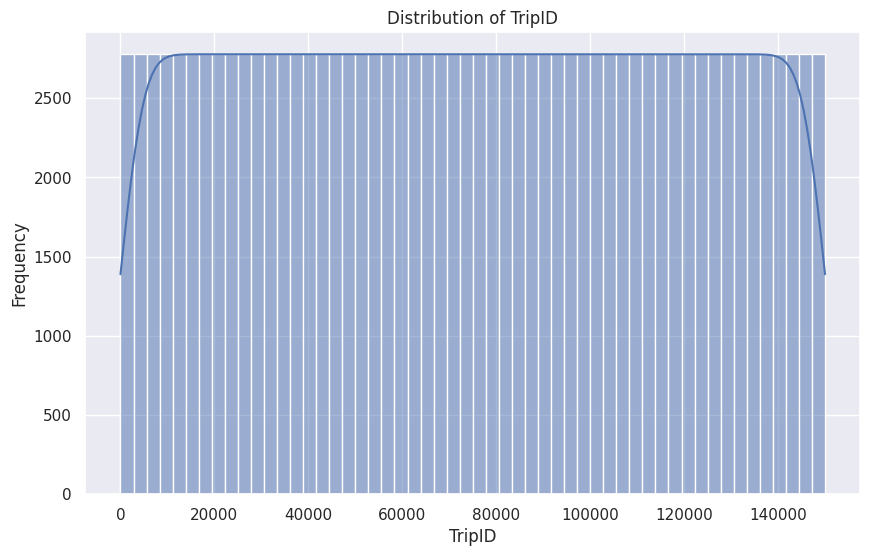

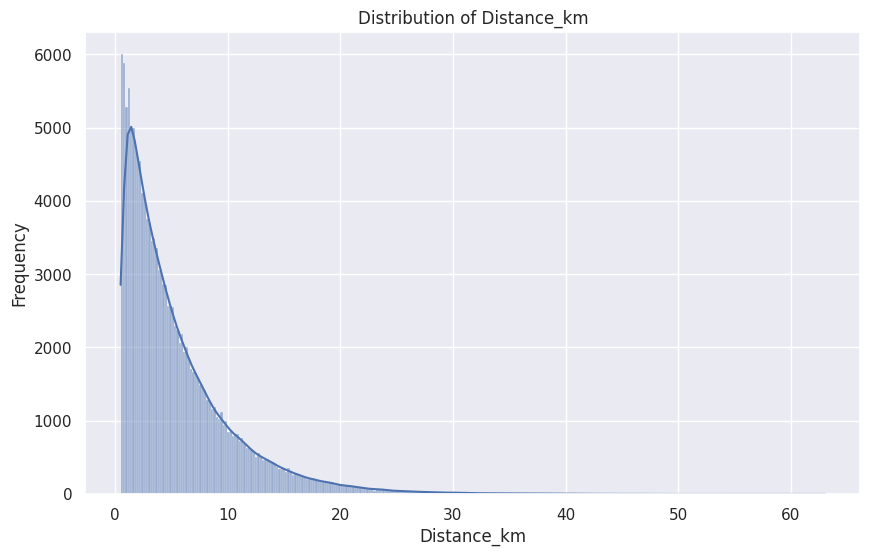

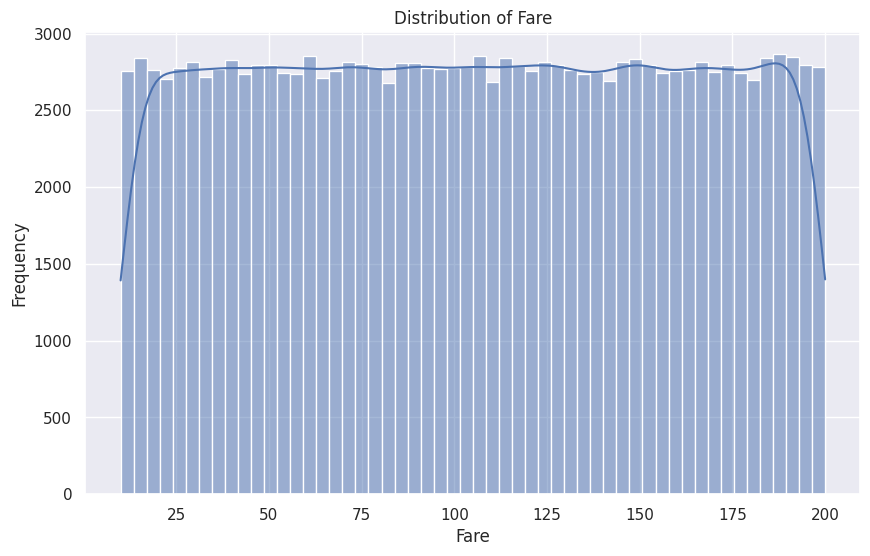

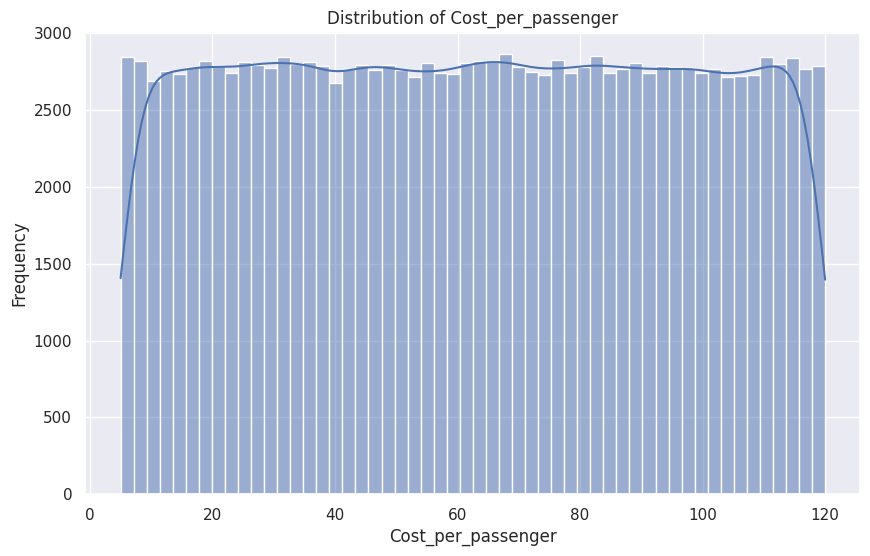

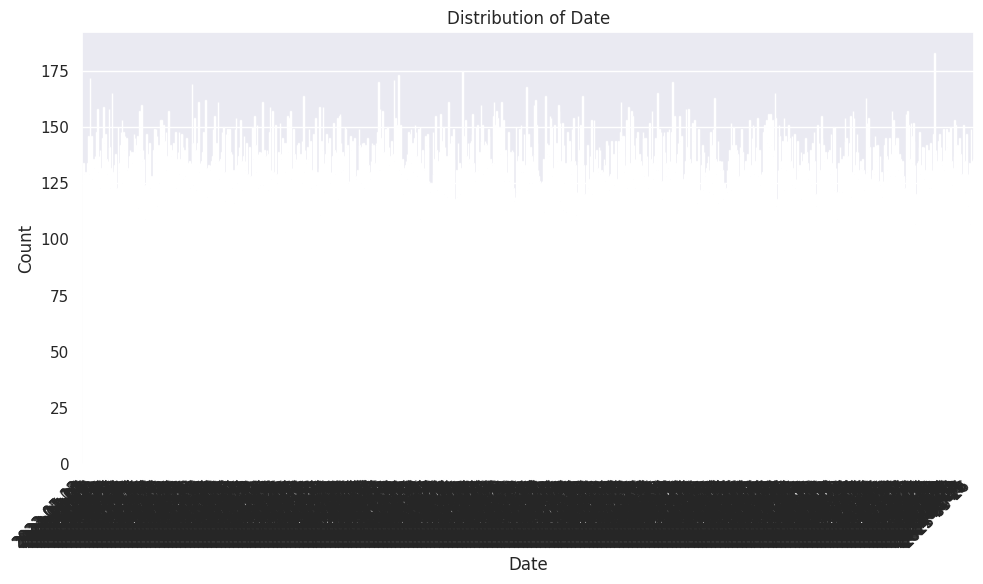

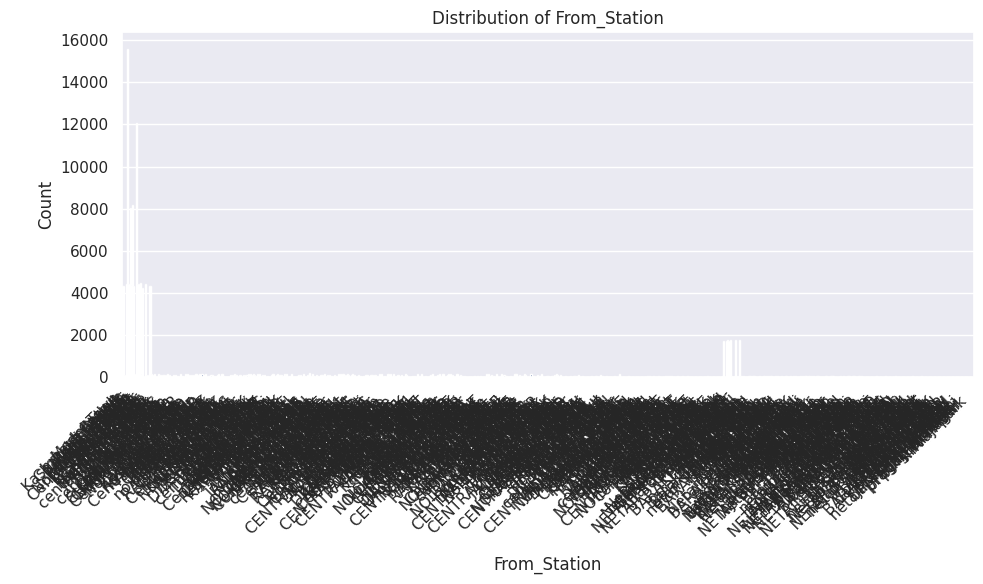

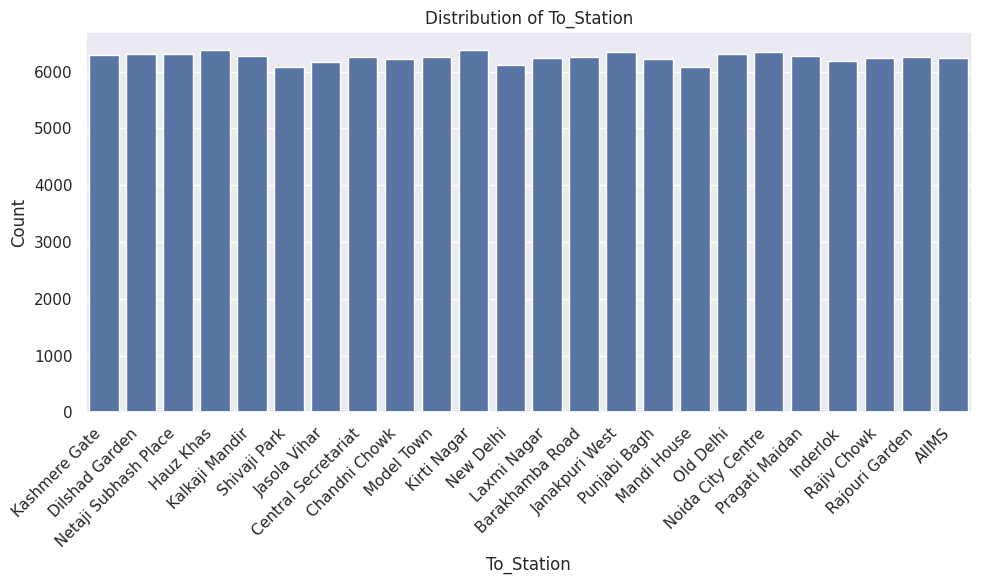

Value counts for Date:
Date
2024-08-10    183
2024-08-01    175
2022-04-07    173
2022-07-05    172
2022-08-23    171
             ... 
2024-11-16    107
2022-08-13    106
2023-08-03    104
2023-11-27     99
2023-02-10     98
Name: count, Length: 1095, dtype: int64

Value counts for From_Station:
From_Station
Rajiv Chowk           15593
Noida City Centre     12049
New Delhi              8173
Mandi House            8044
Dilshad Garden         4461
                      ...  
   punjabi bagh           8
 pragati maidan           7
 BARAKHAMBA ROAD          7
   shivaji park           7
  old delhi               6
Name: count, Length: 663, dtype: int64

Value counts for To_Station:
To_Station
Hauz Khas               6372
Kirti Nagar             6371
Janakpuri West          6340
Noida City Centre       6338
Old Delhi               6313
Netaji Subhash Place    6312
Dilshad Garden          6306
Kashmere Gate           6295
Pragati Maidan          6282
Kalkaji Mandir          6273
Barakhamba 

In [17]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterating through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

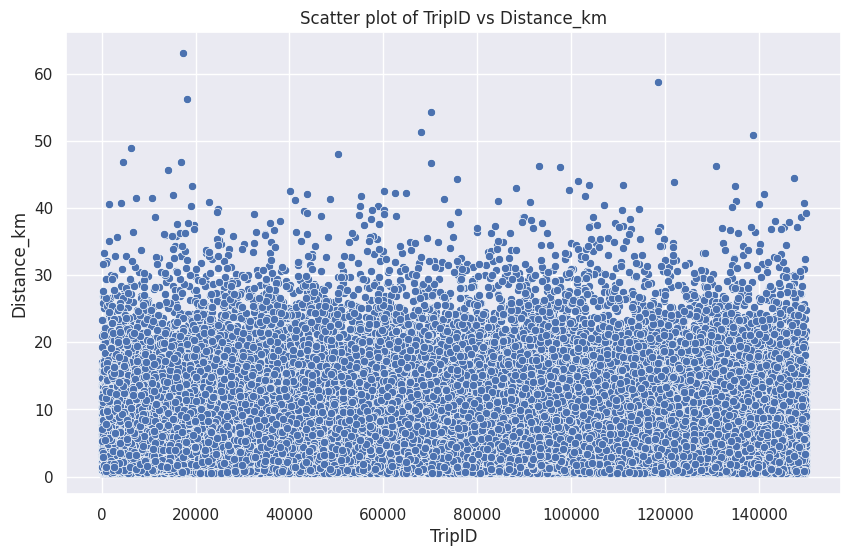

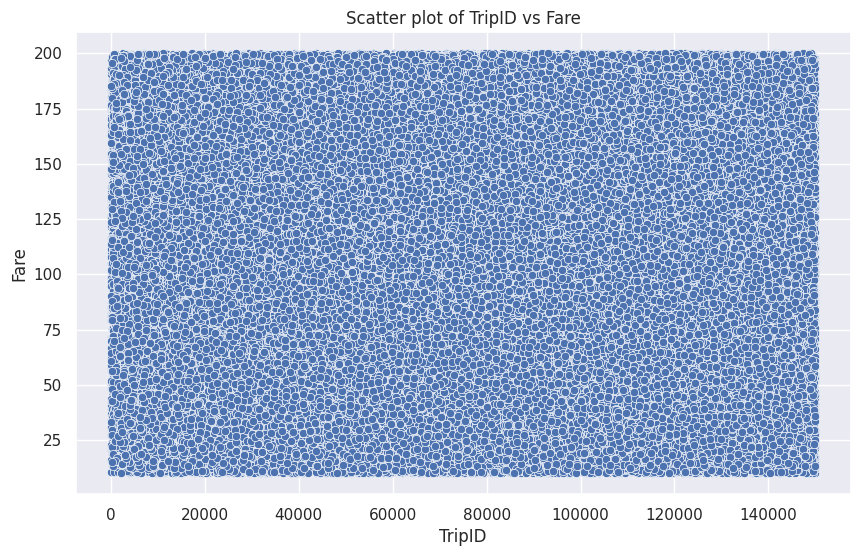

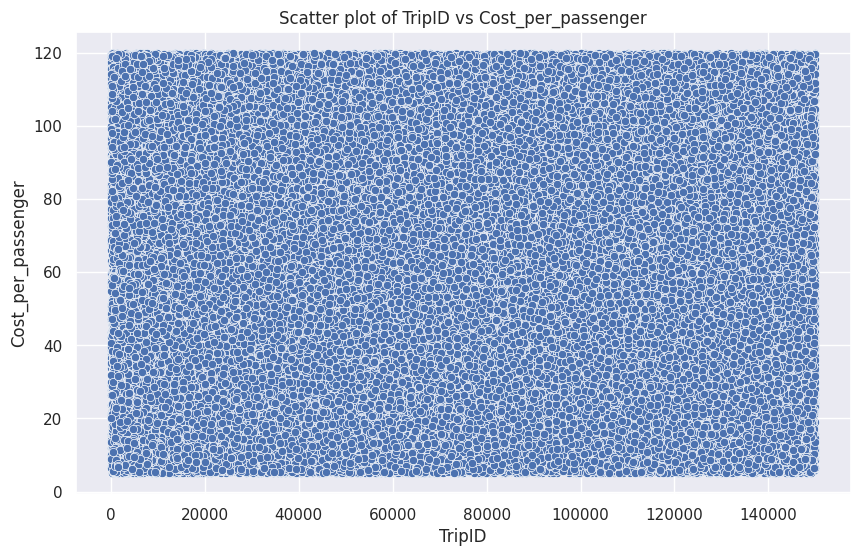

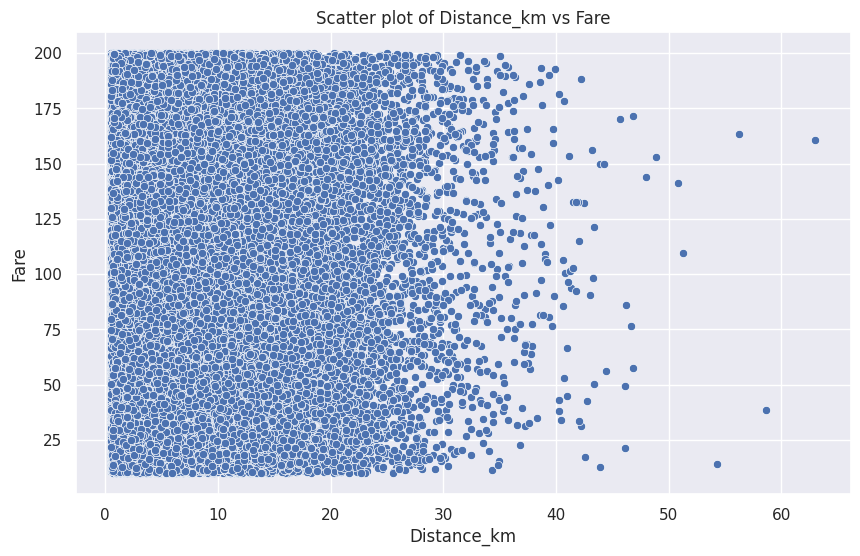

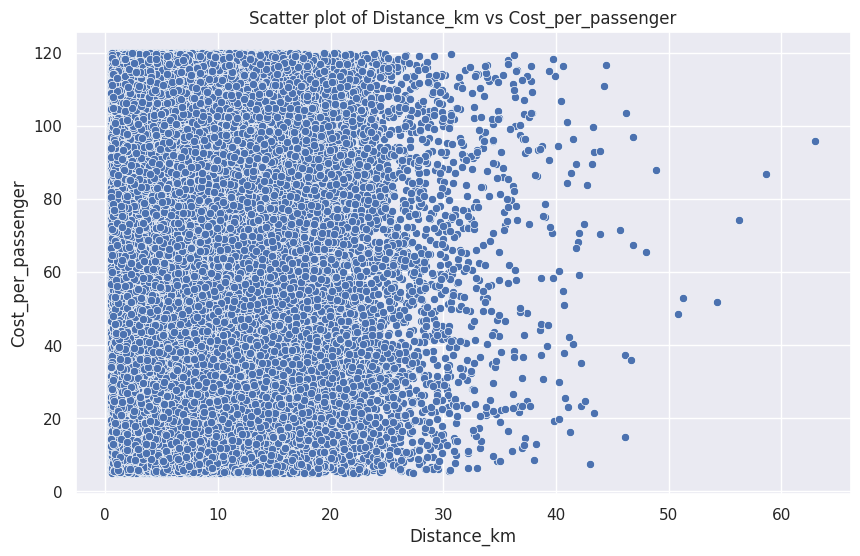

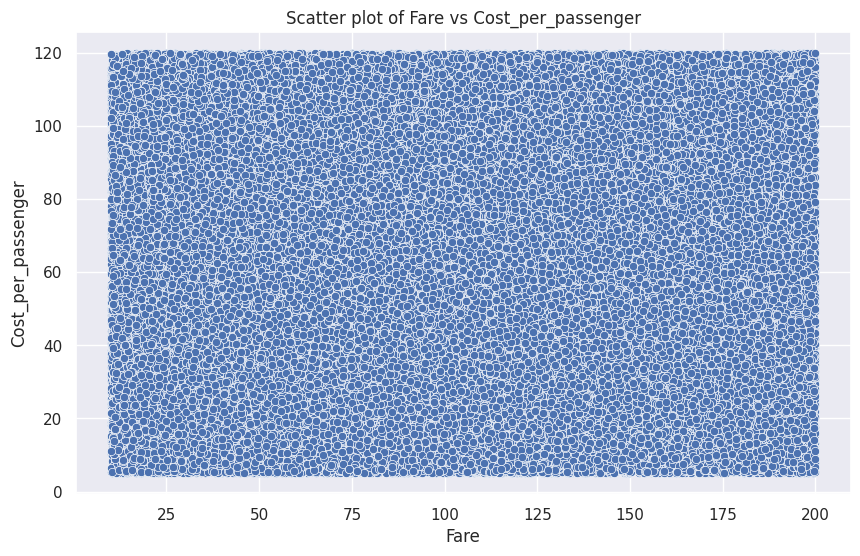

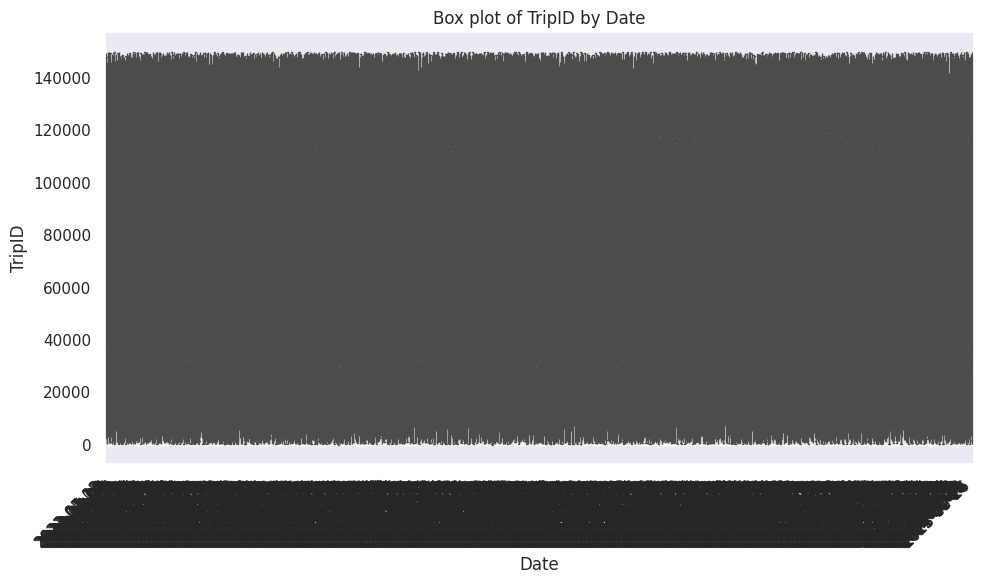

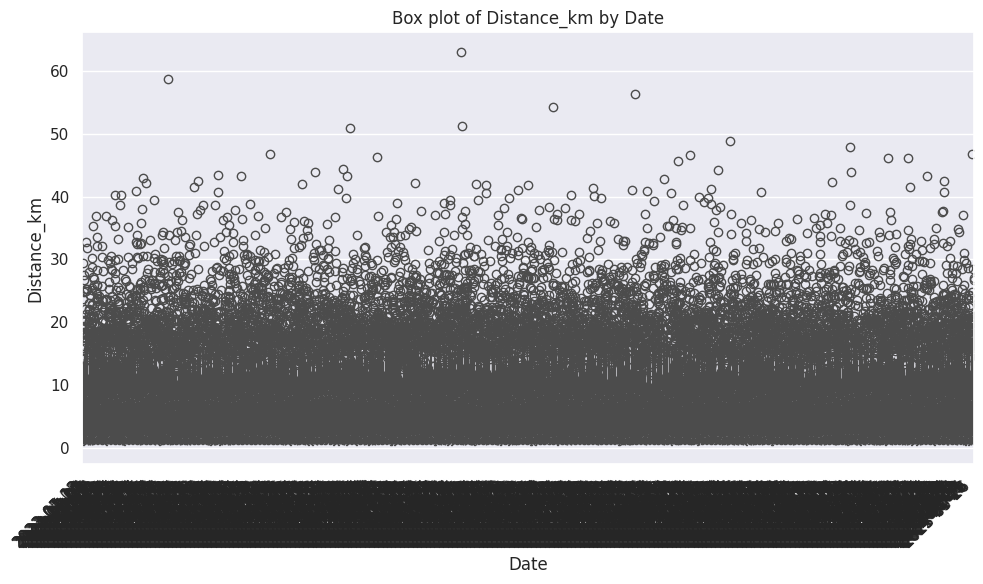

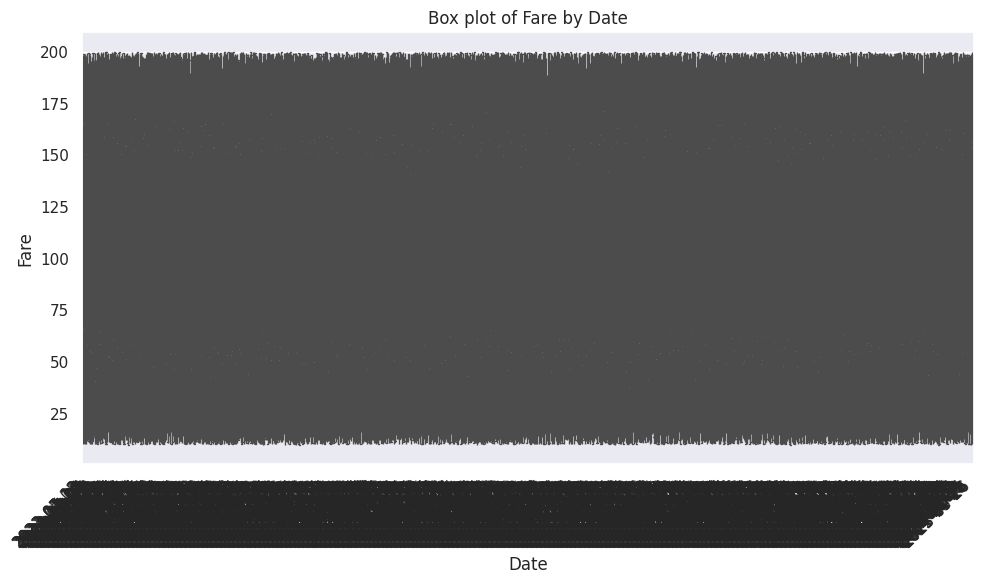

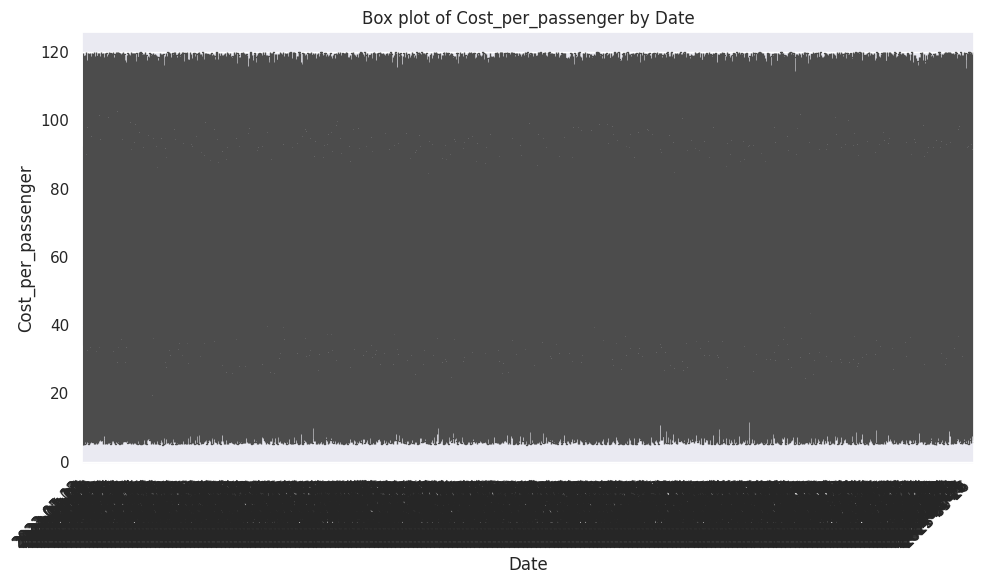

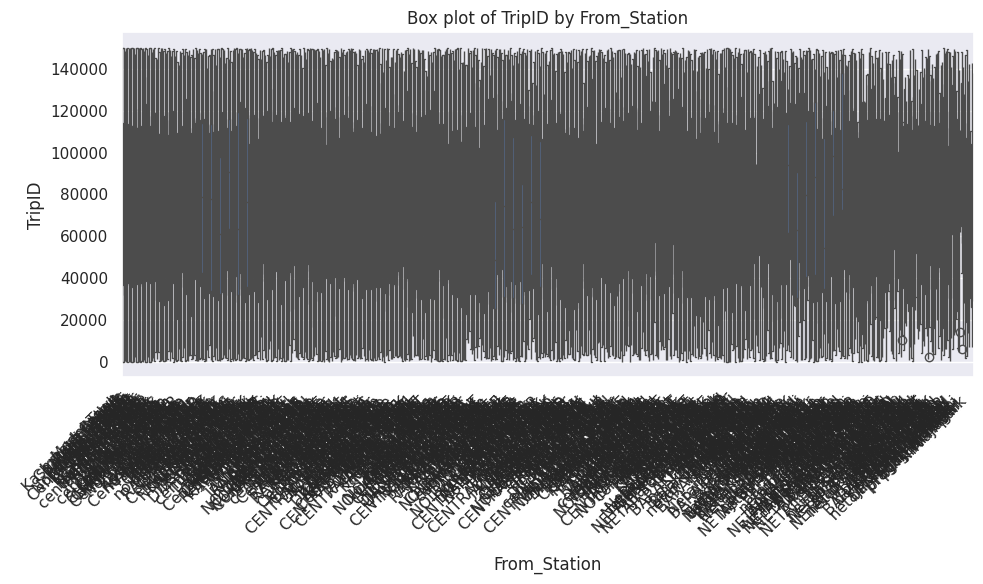

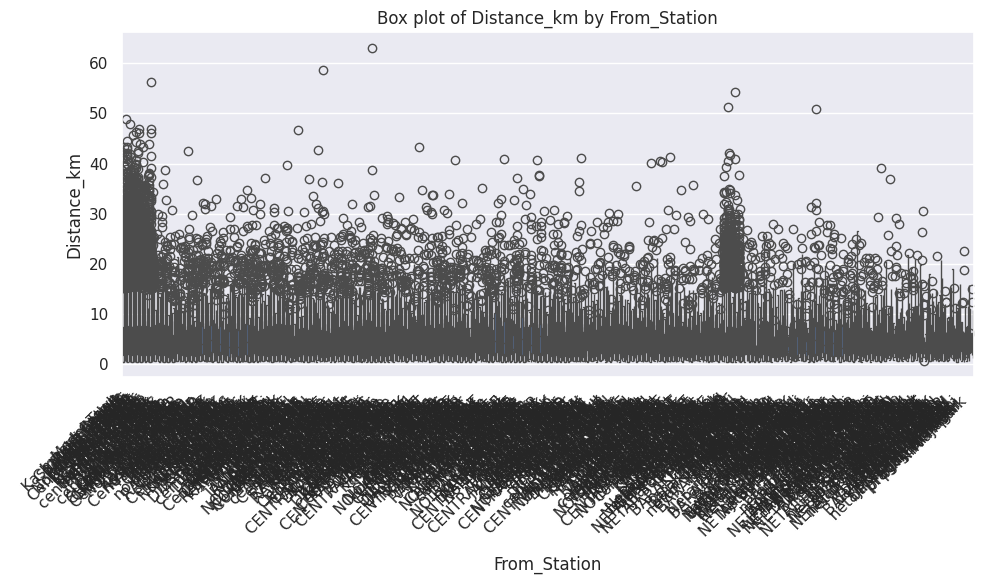

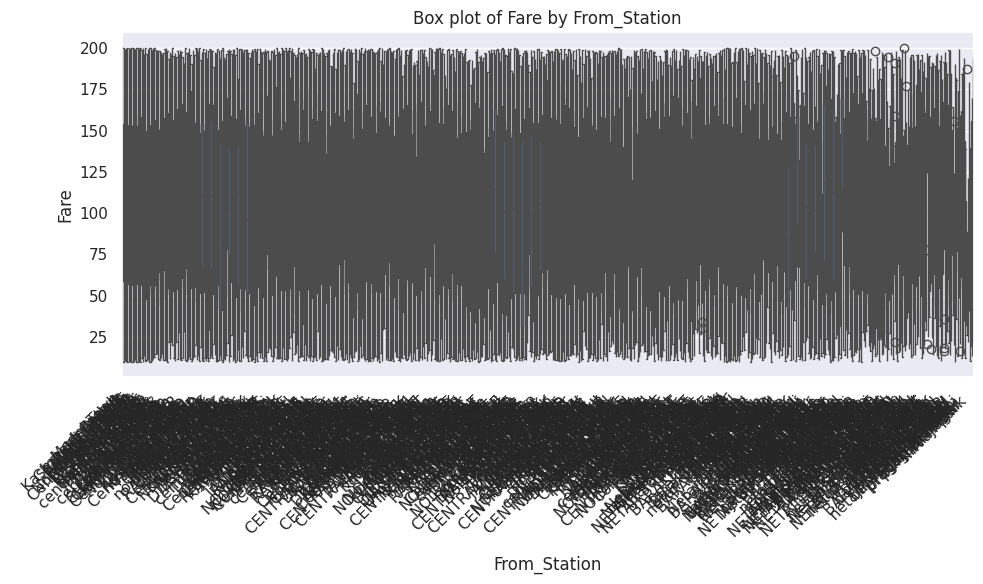

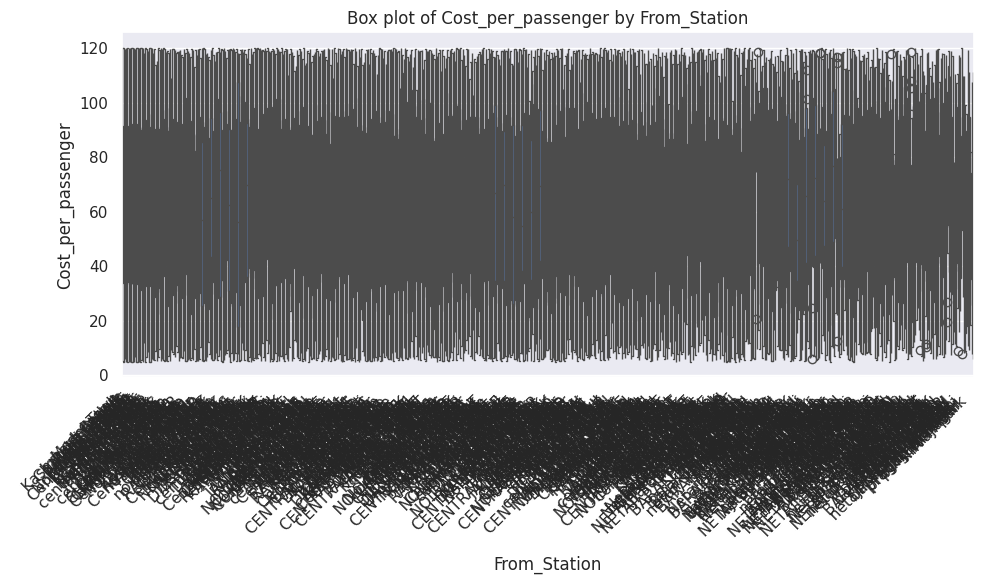

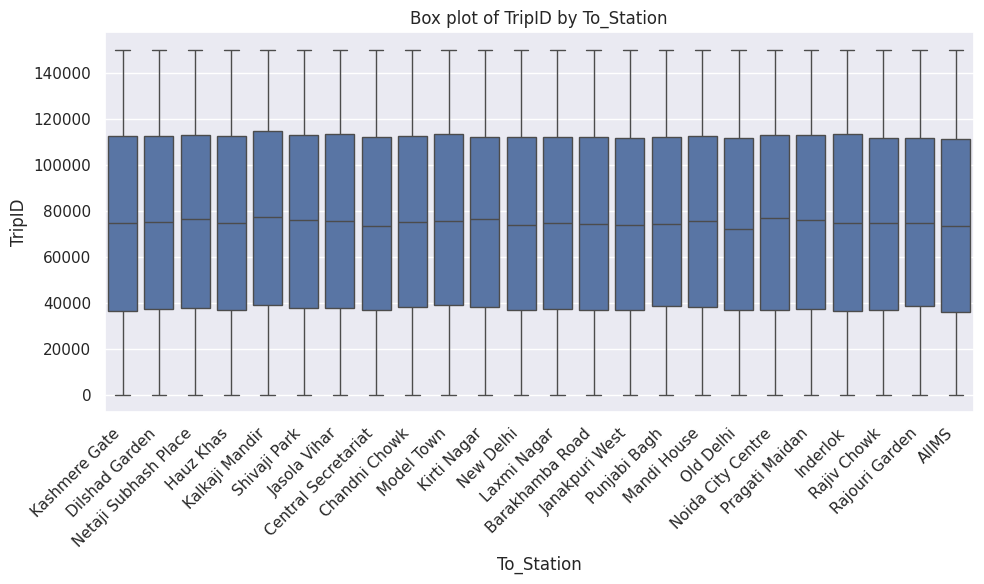

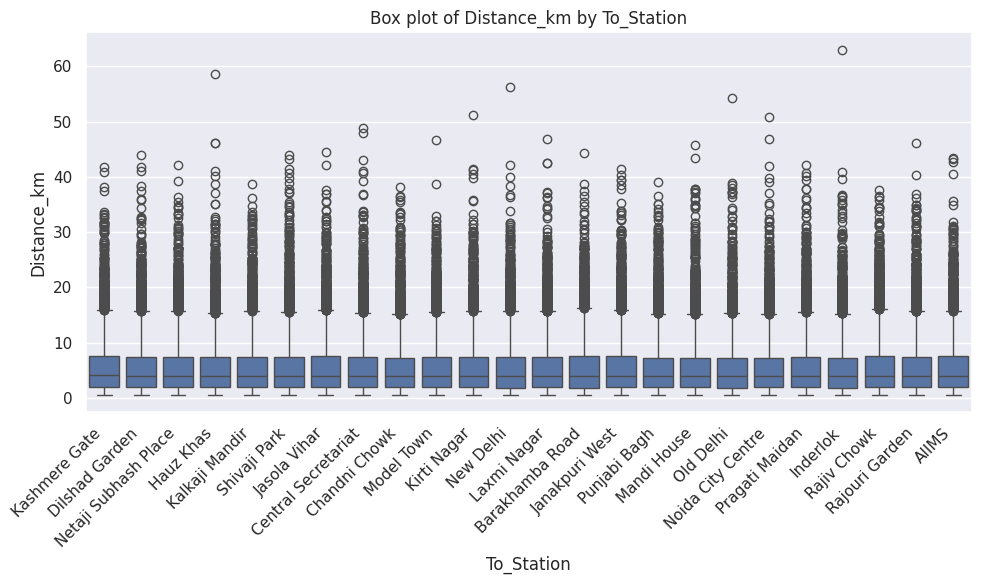

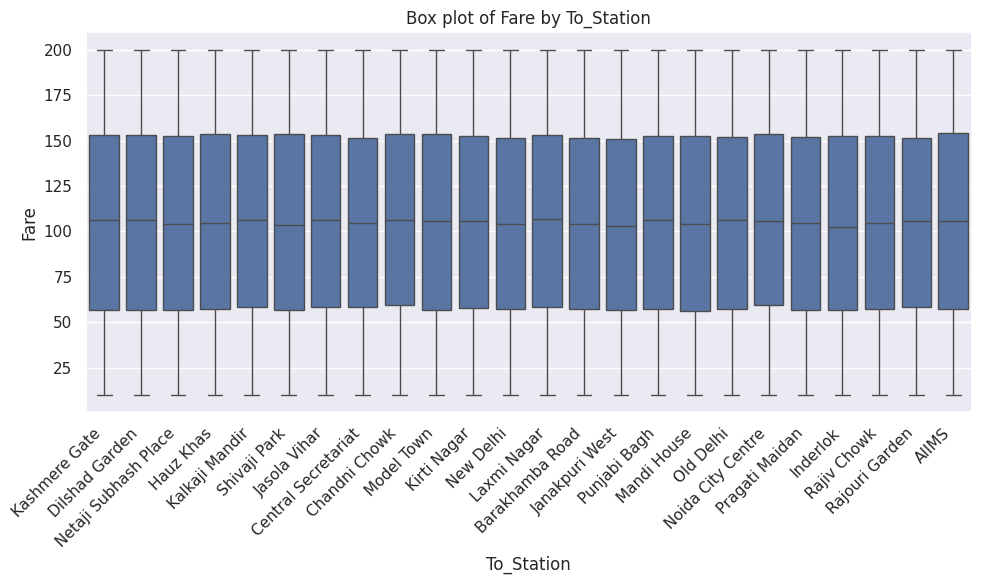

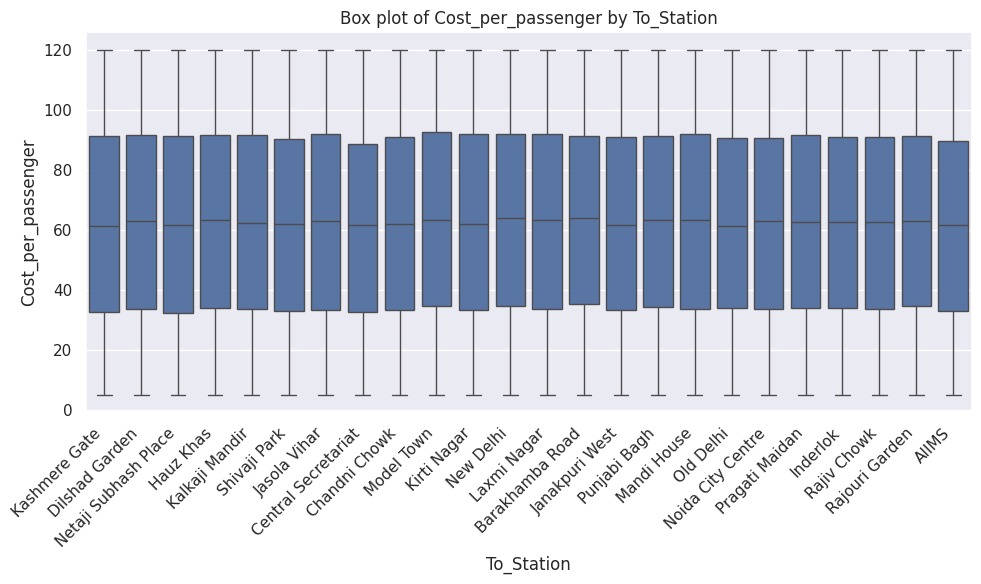

In [18]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

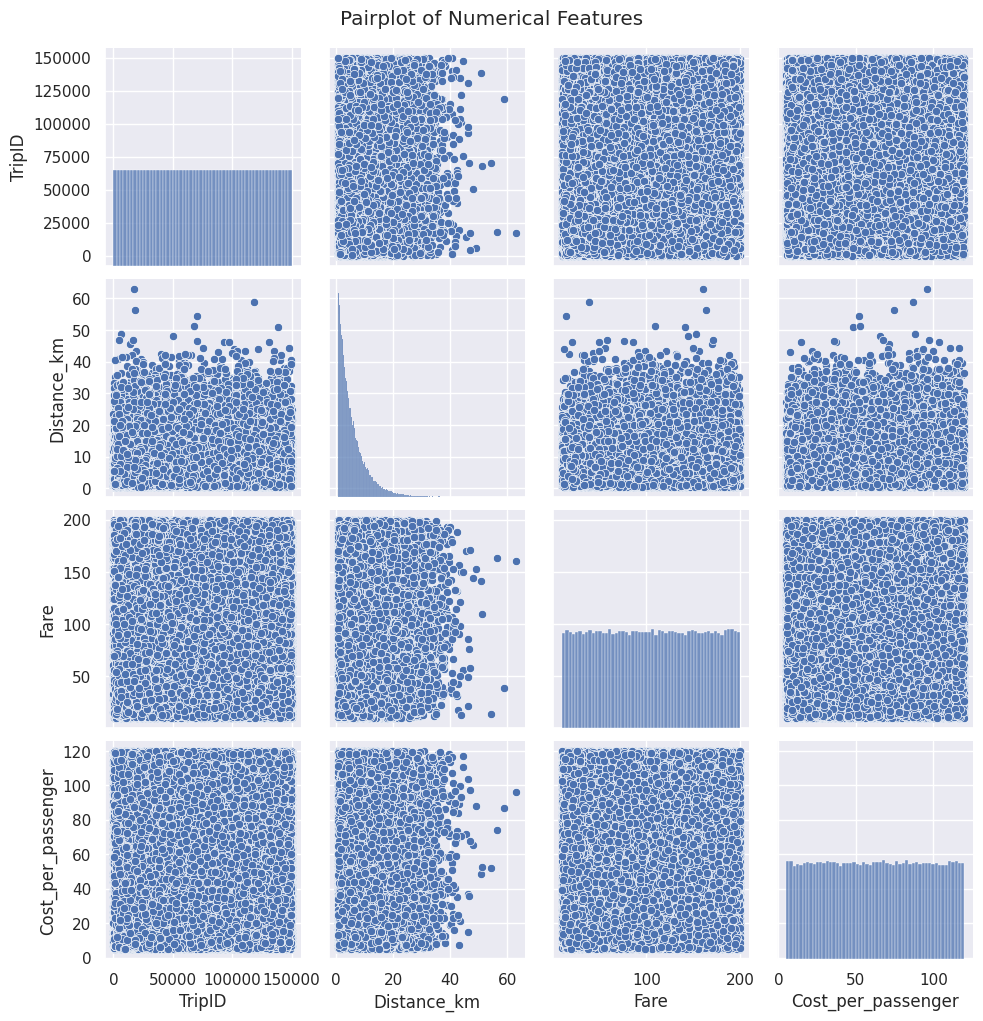

In [20]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

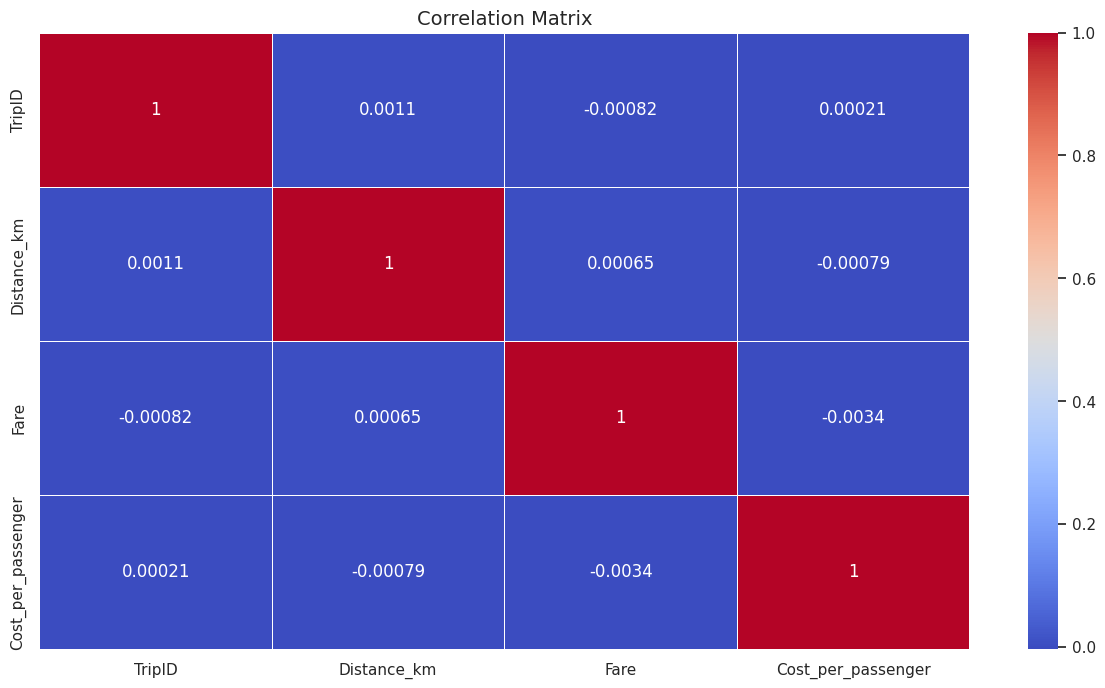

In [19]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You